# Convolutional Neural Network - *Fruits-360*

*Fruits-360* is a database containing images of fruits, vegetables, nuts, and seeds. **(METER CITAÇÃO)**

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

## Dataset & Preprocessing

- **Dataset:** *Fruits-360*
- **Problem Type:** Multi-class Classification
- **Input:** RGB fruit pictures
- **Output:** Fruit class
- **Images Format:** JPG
- **Number of classes:** 253
- **Number of images by split:**
- **Class distribution:**

Following what is given by the original dataset, all the dataset split was preserved, using the provided Training, Validation and Test folders.

- Custom CNN: 100x100
- MobileNetV2/ResNet50: 224x224

We will follow two approaches for the image quality selection based on the provided dataset. For the first custom CNN architecture we will use 100x100 image folder for a fast training and less memory consuption. Later on, when training with a pre-trained network we will use the original image sizes because pre-trained networks often require bigger inputs. We know that this can lead to a huge difference when comparing both models, as said in the dataset description the 100x100 image size contain less information. **(METER CITAÇÃO)**

**talvez usemos as diferentes resoluções nos dois treinos**

As imagens estão organizadas por classe dentro das pastas de Training, Test e Validation. \
26 classes contains full information. The others contain only information about the type, defects and ripeness/maturity state. \
A divisão original é aproximadamente 50% treino, 25% validação e 25% teste.

Although the assignment refers to fruit categories, the selected Fruits-360 version also includes vegetables, nuts and seeds. Therefore, the model was trained as a general object category classifier using all available classes.

Input \
→ Rescaling \
→ Conv2D 32 + MaxPooling \
→ Conv2D 64 + MaxPooling \
→ Conv2D 128 + MaxPooling \
→ GlobalAveragePooling \
→ Dense \
→ Softmax 

Images were resized to a fixed input size because CNNs require inputs with consistent dimensions. Pixel values were normalized to the [0, 1] range to improve numerical stability during training. No manual background removal was applied because the dataset already contains pre-processed images with removed or standardized backgrounds. The original Training, Validation and Test folders were preserved.

Since the current Fruits-360 version may contain images with different original dimensions, all images were resized to a fixed resolution before being passed to the CNN.

Pixel values were normalized from the original [0, 255] range to [0, 1] trying to improve numerical stability and helping the optimizer converge more efficiently during training.

Images were resized to a fixed input size to ensure compatibility with the CNN architecture. Pixel values were rescaled to the [0, 1] range to improve numerical stability and accelerate convergence. The original train, validation and test split was preserved to avoid data leakage.

No manual segmentation was applied because the Fruits-360 images are already pre-segmented and captured on a uniform white background.

| Experimento | Alteração                    | Objetivo                            |
| ----------- | ---------------------------- | ----------------------------------- |
| E1          | Baseline CNN                 | Modelo inicial                      |
| E2          | Mais filtros: 64/128/256     | Avaliar impacto da capacidade       |
| E3          | Kernel size 5x5 vs 3x3       | Avaliar filtros maiores             |
| E4          | Padding `same` vs `valid`    | Avaliar preservação espacial        |
| E5          | Stride 1 vs stride 2         | Avaliar redução espacial            |
| E6          | MaxPooling vs AveragePooling | Comparar pooling methods            |
| E7          | Sem pooling ou menos pooling | Avaliar impacto da redução espacial |
| E8          | Sem data augmentation        | Baseline sem aumento artificial     |
| E9          | Com data augmentation        | Avaliar generalização               |
| E10         | CNN com Dropout/BatchNorm    | Mitigar overfitting                 |
| E11         | MobileNetV2 ou ResNet50      | Transfer learning                   |


| Exp. |     Filters |     Kernel | Stride | Padding | Pooling | Augmentation | Test Acc | Precision | Recall |  F1 |
| ---- | ----------: | ---------: | -----: | ------- | ------- | ------------ | -------: | --------: | -----: | --: |
| E1   |   32-64-128 |        3x3 |      1 | same    | max     | no           |      ... |       ... |    ... | ... |
| E2   |  64-128-256 |        3x3 |      1 | same    | max     | no           |      ... |       ... |    ... | ... |
| E3   |   32-64-128 |        5x5 |      1 | same    | max     | no           |      ... |       ... |    ... | ... |
| E4   |   32-64-128 |        3x3 |      1 | valid   | max     | no           |      ... |       ... |    ... | ... |
| E5   |   32-64-128 |        3x3 |      2 | same    | max     | no           |      ... |       ... |    ... | ... |
| E6   |   32-64-128 |        3x3 |      1 | same    | average | no           |      ... |       ... |    ... | ... |
| E9   |   32-64-128 |        3x3 |      1 | same    | max     | yes          |      ... |       ... |    ... | ... |
| E11  | MobileNetV2 | pretrained |      - | -       | -       | yes          |      ... |       ... |    ... | ... |


A folder de 100x100 só inclui Training e Test, por isso o Training vai ser dividido em Training e Validation. \
asd

In [34]:
base_dir = Path("/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_100x100/fruits-360")

print(base_dir.exists())
print(base_dir)

True
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_100x100/fruits-360


In [35]:
for item in base_dir.iterdir():
    print(item)

/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_100x100/fruits-360/LICENSE
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_100x100/fruits-360/README.md
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_100x100/fruits-360/Test
/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_100x100/fruits-360/Training


In [36]:
TRAIN_DIR = base_dir / "Training"
TEST_DIR = base_dir / "Test"

print("Train:", TRAIN_DIR.exists())
print("Test:", TEST_DIR.exists())

Train: True
Test: True


In [37]:
def count_images_by_class(directory):
    class_counts = {}

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            image_files = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png")) + list(class_dir.glob("*.jpeg"))
            class_counts[class_dir.name] = len(image_files)

    return class_counts


train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

print("Número de classes no treino:", len(train_counts))
print("Número de imagens de treino:", sum(train_counts.values()))
print("Número de imagens de teste:", sum(test_counts.values()))

Número de classes no treino: 258
Número de imagens de treino: 135313
Número de imagens de teste: 45088


In [38]:
list(train_counts.items())[:10]

[('Almonds 1', 232),
 ('Apple 10', 699),
 ('Apple 11', 430),
 ('Apple 12', 466),
 ('Apple 13', 699),
 ('Apple 14', 466),
 ('Apple 17', 610),
 ('Apple 18', 724),
 ('Apple 19', 729),
 ('Apple 20', 702)]

In [39]:
train_classes = set(train_counts.keys())
test_classes = set(test_counts.keys())

print("Classes iguais entre train e test:", train_classes == test_classes)

print("Classes em train mas não em test:", train_classes - test_classes)
print("Classes em test mas não em train:", test_classes - train_classes)

Classes iguais entre train e test: False
Classes em train mas não em test: {'BlackBerry 4'}
Classes em test mas não em train: {'Blackberry 4'}


In [40]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 135313 files belonging to 258 classes.
Using 108251 files for training.
Found 135313 files belonging to 258 classes.
Using 27062 files for validation.


In [41]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 45088 files belonging to 258 classes.


In [48]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Primeiras classes:", class_names[:10])

Número de classes: 258
Primeiras classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']


In [49]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

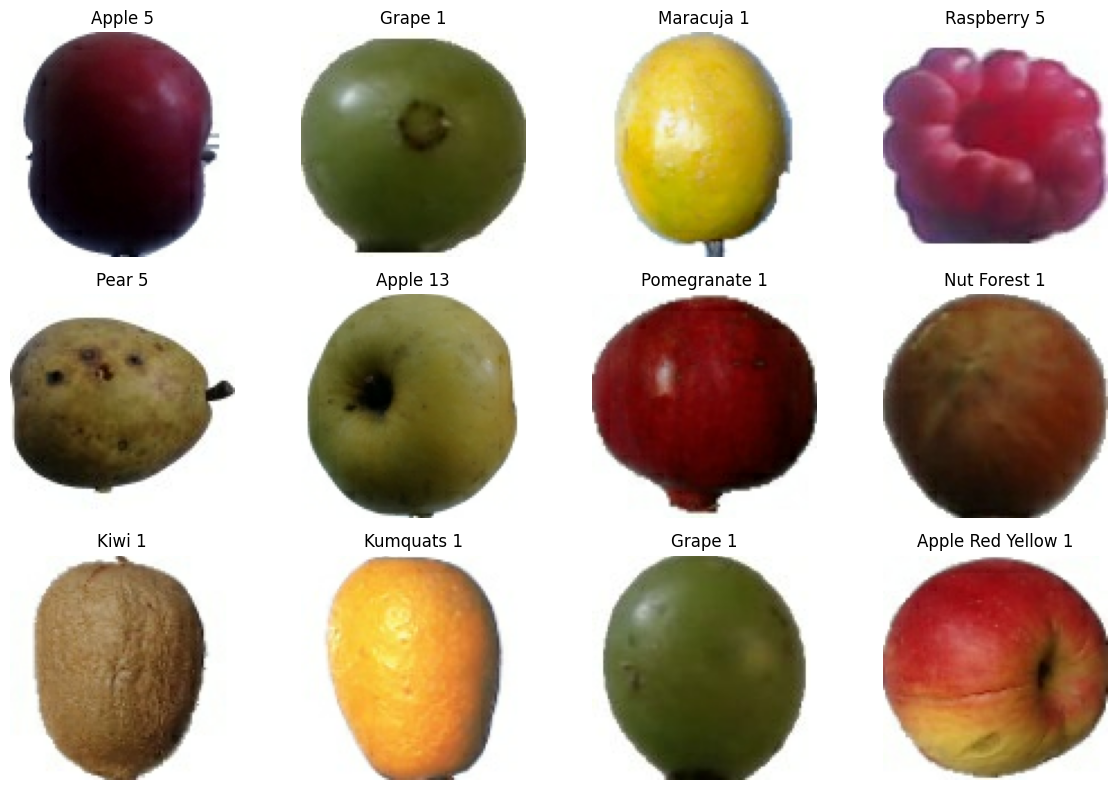

In [50]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
baseline_model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

In [52]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 100, 100, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 100, 100, 32)      896       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 50, 50, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 25, 25, 64)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 25, 25, 128)      

In [53]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

In [54]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
3383/3383 [==============================] - 249s 73ms/step - loss: 1.8099 - accuracy: 0.4930 - val_loss: 0.3362 - val_accuracy: 0.8931 - lr: 0.0010
Epoch 2/5
3383/3383 [==============================] - 246s 73ms/step - loss: 0.5449 - accuracy: 0.8079 - val_loss: 0.1526 - val_accuracy: 0.9585 - lr: 0.0010
Epoch 3/5
3383/3383 [==============================] - 247s 73ms/step - loss: 0.3521 - accuracy: 0.8724 - val_loss: 0.0780 - val_accuracy: 0.9785 - lr: 0.0010
Epoch 4/5
3383/3383 [==============================] - 244s 72ms/step - loss: 0.2666 - accuracy: 0.9009 - val_loss: 0.0682 - val_accuracy: 0.9787 - lr: 0.0010
Epoch 5/5
3383/3383 [==============================] - 255s 75ms/step - loss: 0.2130 - accuracy: 0.9202 - val_loss: 0.0409 - val_accuracy: 0.9886 - lr: 0.0010


In [55]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

1409/1409 [==============================] - 34s 24ms/step - loss: 1.0841 - accuracy: 0.9405
Test loss: 1.0841
Test accuracy: 94.05%


In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = baseline_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.96      0.98       231
              Apple 11       0.82      1.00      0.90       142
              Apple 12       0.97      1.00      0.99       154
              Apple 13       0.98      1.00      0.99       235
              Apple 14       0.88      1.00      0.93       154
              Apple 17       1.00      1.00      1.00       201
              Apple 18       1.00      1.00      1.00       240
              Apple 19       0.98      1.00      0.99       241
              Apple 20       1.00      1.00      1.00       234
              Apple 21       1.00      1.00      1.00       162
              Apple 22       0.96      0.92      0.94       231
              Apple 23       1.00      0.96      0.98       156
               Apple 5       1.00      1.00      1.00       146
               Apple 6       0.95      

In [57]:
results = []

results.append({
    "experiment": "E1 - Baseline CNN",
    "input_size": "100x100",
    "filters": "32-64-128",
    "kernel_size": "3x3",
    "stride": 1,
    "padding": "same",
    "pooling": "max",
    "augmentation": "no",
    "params": baseline_model.count_params(),
    "test_accuracy": test_accuracy,
    "test_loss": test_loss
})

results_df = pd.DataFrame(results)
results_df

,experiment,input_size,filters,kernel_size,stride,padding,pooling,augmentation,params,test_accuracy,test_loss
0,E1 - Baseline CNN,100x100,32-64-128,3x3,1,same,max,no,143042,0.940539,1.08412


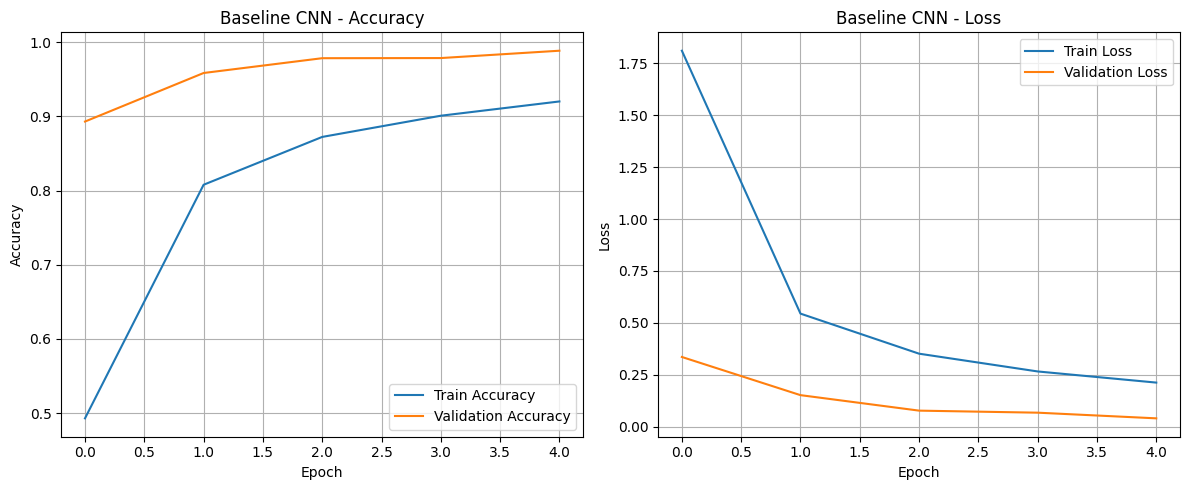

In [58]:
def plot_training_curves(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_baseline, "Baseline CNN")

In [67]:
from pathlib import Path
import tensorflow as tf

BASE_DIR = Path("/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size")

TRAIN_DIR = BASE_DIR / "Training"
VALID_DIR = BASE_DIR / "Validation"
TEST_DIR = BASE_DIR / "Test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Primeiras classes:", class_names[:10])

Found 50073 files belonging to 142 classes.
Found 25044 files belonging to 142 classes.
Found 24890 files belonging to 142 classes.
Número de classes: 142
Primeiras classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']


In [68]:
print("Train classes:", len(train_ds.class_names) if hasattr(train_ds, "class_names") else "class_names lost")
print("Valid classes:", len(valid_ds.class_names) if hasattr(valid_ds, "class_names") else "class_names lost")

Train classes: 142
Valid classes: 142


In [69]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

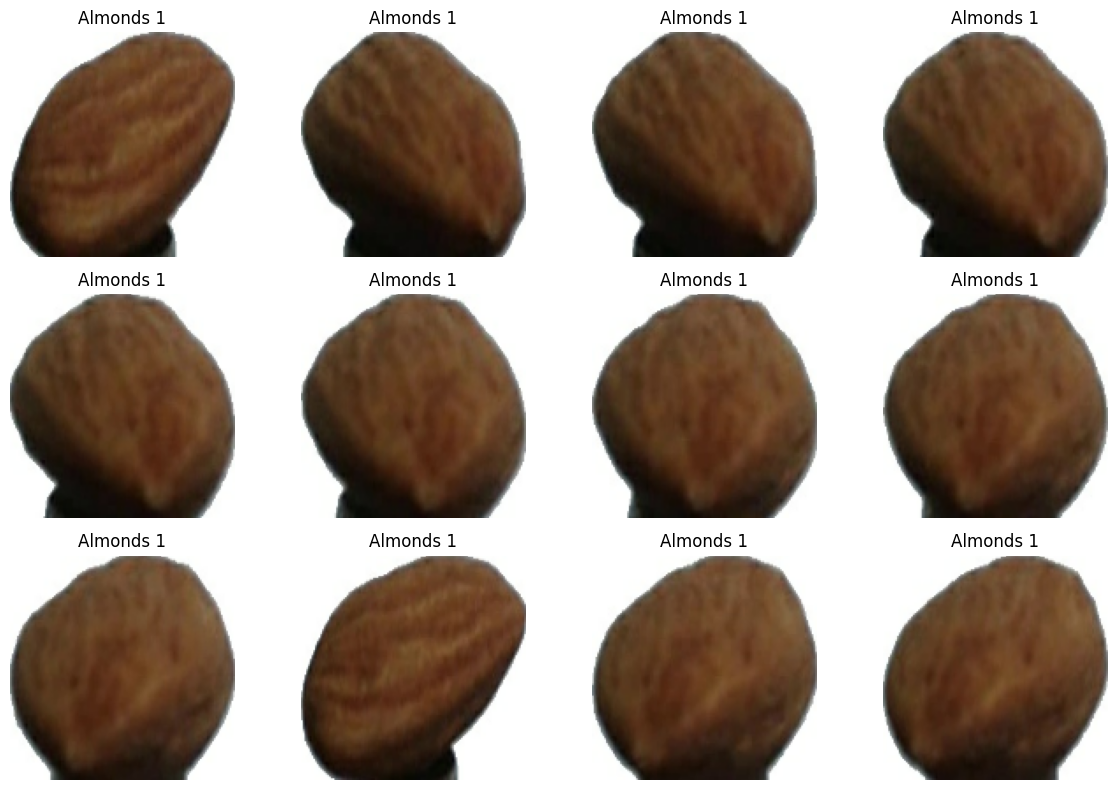

In [70]:
plt.figure(figsize=(12, 8))

for images, labels in valid_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

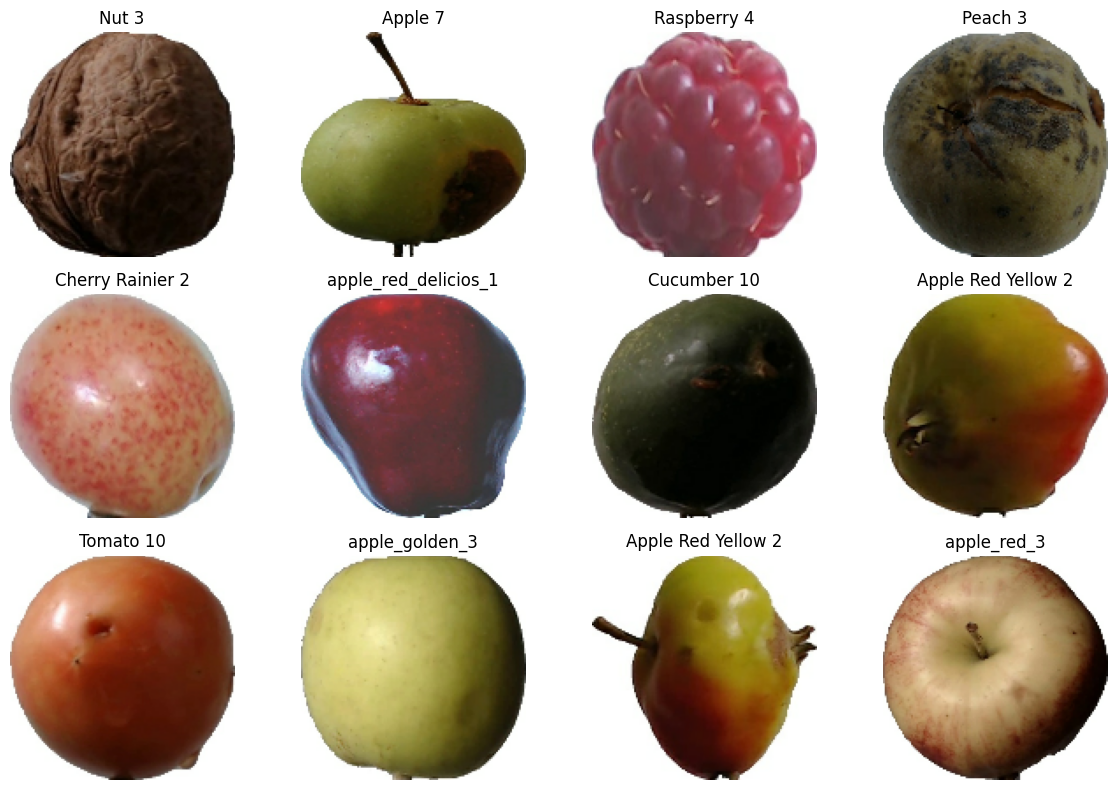

In [61]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [62]:
baseline_model = tf.keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

In [71]:
print("num_classes:", num_classes)
print("Last layer units:", baseline_model.layers[-1].units)

num_classes: 142
Last layer units: 142


In [63]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 32, 32, 128)      

In [64]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

---

---

In [72]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

# Opcional: reduzir logs do TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [76]:
BASE_DIR = Path("/app/shared/APPROF_ADF_M1B_1200742_1201118/APPROF_ADF_M1B_1200742_1201118_Repository/data/fruits-360_original-size/fruits-360-original-size")

TRAIN_DIR = BASE_DIR / "Training"
VALID_DIR = BASE_DIR / "Validation"
TEST_DIR = BASE_DIR / "Test"

print("BASE_DIR exists:", BASE_DIR.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("VALID_DIR exists:", VALID_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def normalize_label(label):
    label = label.strip()
    label = label.replace("_", " ")
    label = " ".join(label.split())
    label = label.lower()
    return label

def build_dataframe(directory, split_name):
    rows = []

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            original_label = class_dir.name
            normalized_label = normalize_label(original_label)

            for file_path in class_dir.rglob("*"):
                if file_path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({
                        "filepath": str(file_path),
                        "original_label": original_label,
                        "label": normalized_label,
                        "split": split_name
                    })

    return pd.DataFrame(rows)

train_df = build_dataframe(TRAIN_DIR, "train")
valid_df = build_dataframe(VALID_DIR, "validation")
test_df = build_dataframe(TEST_DIR, "test")

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

train_df.head()

BASE_DIR exists: True
TRAIN_DIR exists: True
VALID_DIR exists: True
TEST_DIR exists: True
Train: (50073, 4)
Validation: (25044, 4)
Test: (24890, 4)


,filepath,original_label,label,split
0,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
1,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
2,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
3,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train
4,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,train


In [77]:
train_labels = set(train_df["label"].unique())
valid_labels = set(valid_df["label"].unique())
test_labels = set(test_df["label"].unique())

print("Train labels:", len(train_labels))
print("Validation labels:", len(valid_labels))
print("Test labels:", len(test_labels))

print("Train == Validation:", train_labels == valid_labels)
print("Train == Test:", train_labels == test_labels)

print("\nIn train not validation:")
print(sorted(train_labels - valid_labels))

print("\nIn validation not train:")
print(sorted(valid_labels - train_labels))

print("\nIn train not test:")
print(sorted(train_labels - test_labels))

print("\nIn test not train:")
print(sorted(test_labels - train_labels))

Train labels: 142
Validation labels: 142
Test labels: 142
Train == Validation: True
Train == Test: False

In train not validation:
[]

In validation not train:
[]

In train not test:
['beans 1', 'grape not ripen 1', 'pear common 1']

In test not train:
['bean pod 1', 'grape 1', 'pear 14']


In [78]:
common_labels = sorted(train_labels & valid_labels & test_labels)

print("Common labels:", len(common_labels))
print("Removed from train:", sorted(train_labels - set(common_labels)))
print("Removed from validation:", sorted(valid_labels - set(common_labels)))
print("Removed from test:", sorted(test_labels - set(common_labels)))

Common labels: 139
Removed from train: ['beans 1', 'grape not ripen 1', 'pear common 1']
Removed from validation: ['beans 1', 'grape not ripen 1', 'pear common 1']
Removed from test: ['bean pod 1', 'grape 1', 'pear 14']


In [79]:
train_df = train_df[train_df["label"].isin(common_labels)].copy()
valid_df = valid_df[valid_df["label"].isin(common_labels)].copy()
test_df = test_df[test_df["label"].isin(common_labels)].copy()

print("Train classes:", train_df["label"].nunique())
print("Validation classes:", valid_df["label"].nunique())
print("Test classes:", test_df["label"].nunique())

print("Train images:", len(train_df))
print("Validation images:", len(valid_df))
print("Test images:", len(test_df))

Train classes: 139
Validation classes: 139
Test classes: 139
Train images: 49146
Validation images: 24579
Test images: 24430


During dataset inspection, three label inconsistencies were found between the Training/Validation and Test folders. Since a model cannot be fairly evaluated on classes that are not present in the training set, only the classes common to Training, Validation and Test were retained for the controlled experiments. This resulted in 139 classes.

In [82]:
class_names = common_labels
num_classes = len(class_names)

label_to_index = {label: idx for idx, label in enumerate(class_names)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

train_df["label_index"] = train_df["label"].map(label_to_index)
valid_df["label_index"] = valid_df["label"].map(label_to_index)
test_df["label_index"] = test_df["label"].map(label_to_index)

print("Number of classes:", num_classes)

train_df[["filepath", "original_label", "label", "label_index", "split"]].head()

Number of classes: 139


,filepath,original_label,label,label_index,split
0,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,0,train
1,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,0,train
2,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,0,train
3,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,0,train
4,/app/shared/APPROF_ADF_M1B_1200742_1201118/APP...,Almonds 1,almonds 1,0,train


In [83]:
print(train_df["label_index"].isna().sum())
print(valid_df["label_index"].isna().sum())
print(test_df["label_index"].isna().sum())

0
0
0


In [84]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [85]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)

    return image, label


def dataframe_to_dataset(df, shuffle=False):
    filepaths = df["filepath"].values
    labels = df["label_index"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = dataframe_to_dataset(train_df, shuffle=True)
valid_ds = dataframe_to_dataset(valid_df, shuffle=False)
test_ds = dataframe_to_dataset(test_df, shuffle=False)

In [86]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Pixel min:", tf.reduce_min(images).numpy())
    print("Pixel max:", tf.reduce_max(images).numpy())
    print("Labels:", labels[:10].numpy())

Images shape: (32, 100, 100, 3)
Labels shape: (32,)
Pixel min: 0.0
Pixel max: 255.0
Labels: [109  14  14  97  64 119  75  62 107 111]


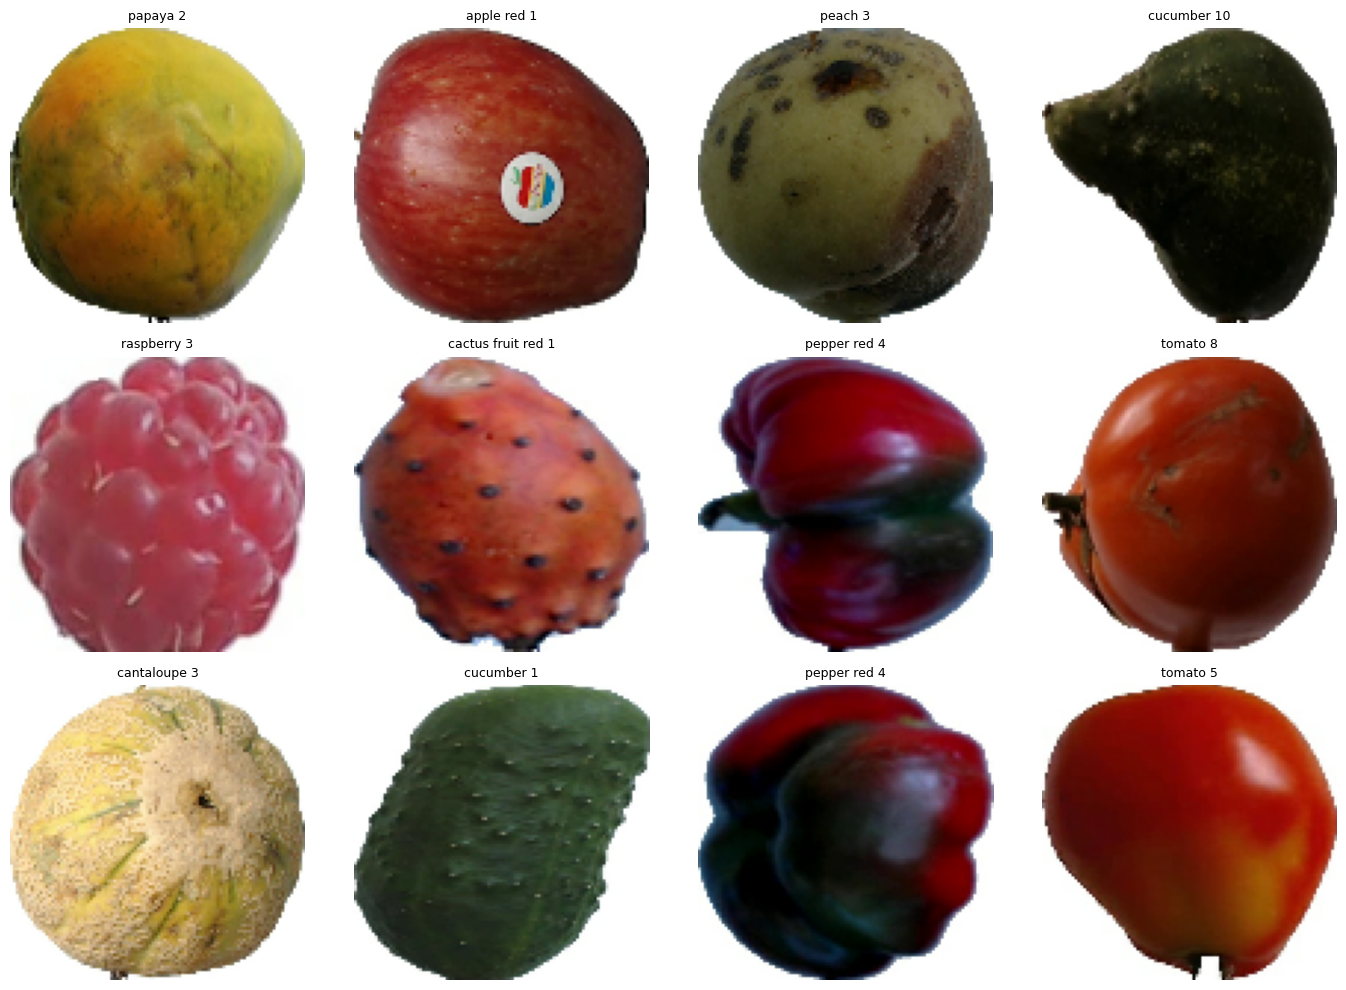

In [87]:
plt.figure(figsize=(14, 10))

for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(index_to_label[int(labels[i])], fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

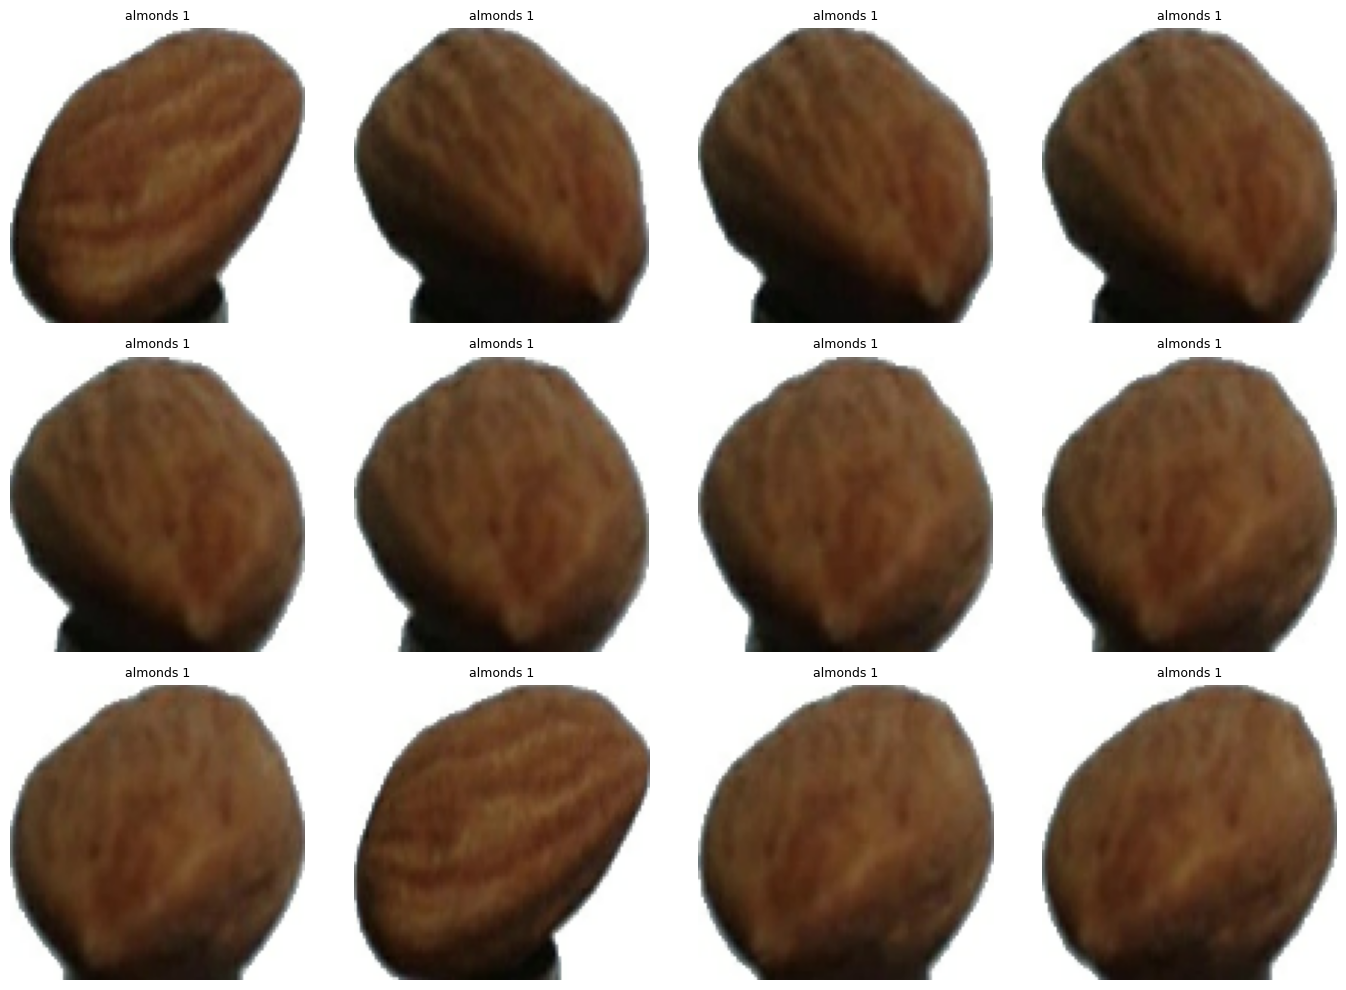

In [88]:
plt.figure(figsize=(14, 10))

for images, labels in valid_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(index_to_label[int(labels[i])], fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [89]:
def build_baseline_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model

In [90]:
baseline_model = build_baseline_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=num_classes
)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

print("num_classes:", num_classes)
print("last layer units:", baseline_model.layers[-1].units)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 100, 100, 3)       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 100, 100, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 100, 100, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 50, 50, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 50, 50, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 50, 50, 64)      

In [91]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

In [92]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
1536/1536 [==============================] - 231s 150ms/step - loss: 1.6050 - accuracy: 0.5785 - val_loss: 0.4358 - val_accuracy: 0.8875 - lr: 3.0000e-04
Epoch 2/20
1536/1536 [==============================] - 154s 100ms/step - loss: 0.3703 - accuracy: 0.8894 - val_loss: 0.2676 - val_accuracy: 0.9223 - lr: 3.0000e-04
Epoch 3/20
1536/1536 [==============================] - 287s 187ms/step - loss: 0.1928 - accuracy: 0.9429 - val_loss: 0.0525 - val_accuracy: 0.9887 - lr: 3.0000e-04
Epoch 4/20
1536/1536 [==============================] - 304s 198ms/step - loss: 0.1154 - accuracy: 0.9676 - val_loss: 0.0667 - val_accuracy: 0.9790 - lr: 3.0000e-04
Epoch 5/20
1536/1536 [==============================] - 246s 160ms/step - loss: 0.0794 - accuracy: 0.9784 - val_loss: 0.1780 - val_accuracy: 0.9344 - lr: 3.0000e-04
Epoch 6/20
1536/1536 [==============================] - 147s 96ms/step - loss: 0.0341 - accuracy: 0.9929 - val_loss: 0.0056 - val_accuracy: 0.9996 - lr: 9.0000e-05
Epoch 7/20


In [93]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

764/764 [==============================] - 33s 43ms/step - loss: 4.5748e-04 - accuracy: 1.0000
Test loss: 0.0005
Test accuracy: 100.00%


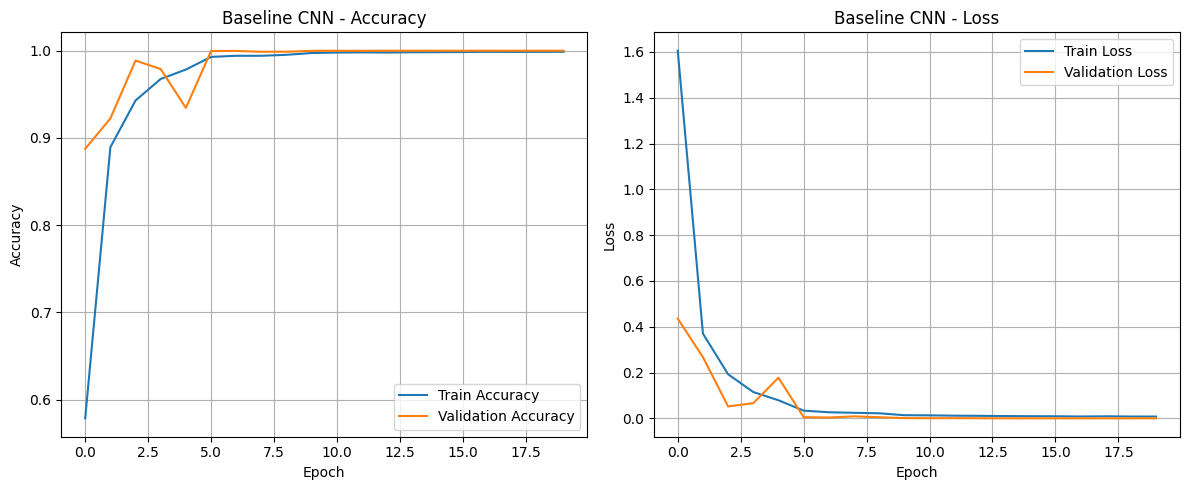

In [94]:
def plot_training_curves(history, title="Training Curves"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_training_curves(history_baseline, "Baseline CNN")

In [95]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = baseline_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

                        precision    recall  f1-score   support

             almonds 1       1.00      1.00      1.00        77
              apple 10       1.00      1.00      1.00       231
              apple 11       1.00      1.00      1.00       142
              apple 12       1.00      1.00      1.00       154
              apple 13       1.00      1.00      1.00       231
              apple 14       1.00      1.00      1.00       154
              apple 17       1.00      1.00      1.00       243
              apple 18       1.00      1.00      1.00       242
              apple 19       1.00      1.00      1.00       241
              apple 20       1.00      1.00      1.00       234
              apple 21       1.00      1.00      1.00       159
              apple 22       1.00      1.00      1.00       231
              apple 23       1.00      1.00      1.00       156
               apple 5       1.00      1.00      1.00       146
               apple 6       1.00      

In [96]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(num_classes),
    zero_division=0
)

class_metrics_df = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
})

bad_classes = class_metrics_df[
    (class_metrics_df["precision"] < 0.70) |
    (class_metrics_df["recall"] < 0.70)
].sort_values("f1_score")

bad_classes

,class,precision,recall,f1_score,support


In [97]:
results = []

results.append({
    "experiment": "E1 - Baseline CNN",
    "input_size": f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
    "num_classes": num_classes,
    "filters": "32-64-128",
    "kernel_size": "3x3",
    "padding": "same",
    "pooling": "max",
    "augmentation": "no",
    "parameters": baseline_model.count_params(),
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "best_train_accuracy": max(history_baseline.history["accuracy"]),
    "best_val_accuracy": max(history_baseline.history["val_accuracy"])
})

results_df = pd.DataFrame(results)
results_df

,experiment,input_size,num_classes,filters,kernel_size,padding,pooling,augmentation,parameters,test_loss,test_accuracy,best_train_accuracy,best_val_accuracy
0,E1 - Baseline CNN,100x100,139,32-64-128,3x3,same,max,no,128587,0.000457,1.0,0.998759,1.0


In [98]:
# Verificar duplicados exatos entre splits
import hashlib

def file_hash(filepath):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        hasher.update(f.read())
    return hasher.hexdigest()

train_df["hash"] = train_df["filepath"].apply(file_hash)
valid_df["hash"] = valid_df["filepath"].apply(file_hash)
test_df["hash"] = test_df["filepath"].apply(file_hash)

print("Train ∩ Validation:", len(set(train_df["hash"]) & set(valid_df["hash"])))
print("Train ∩ Test:", len(set(train_df["hash"]) & set(test_df["hash"])))
print("Validation ∩ Test:", len(set(valid_df["hash"]) & set(test_df["hash"])))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 1
